In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## Read in data on number of h-bonds

In [2]:
# set number of independent simulations

num_ArkA17_bound_sims = 10
num_ArkA17_bound_NaCl_sims = 10
num_ArkA12_bound_sims = 10
num_ArkA12_bound_NaCl_sims = 10
num_ArkA12_binding_sims = 50
num_ArkA12_binding_NaCl_sims = 50

In [3]:
# read in number of h-bond data

ArkA17_bound_hb = pd.read_table(
    '/data/kball/SH3_binding/salt_paper_analysis/AbpSH3_ArkA17/num_hb.dat', sep = '\s+')
ArkA17_bound_NaCl_hb = pd.read_table(
    '/data/kball/SH3_binding/salt_paper_analysis/AbpSH3_ArkA17_NaCl/num_hb.dat', sep = '\s+')

# ArkA17 simulations just looking at central ArkA12 residues
ArkA17_central_bound_hb = pd.read_table(
    '/data/kball/SH3_binding/salt_paper_analysis/AbpSH3_ArkA17/num_hb_ArkA12.dat', sep = '\s+')
ArkA17_central_bound_NaCl_hb = pd.read_table(
    '/data/kball/SH3_binding/salt_paper_analysis/AbpSH3_ArkA17_NaCl/num_hb_ArkA12.dat', sep = '\s+')

ArkA12_bound_hb = pd.read_table(
    '/data/kball/SH3_binding/salt_paper_analysis/AbpSH3_ArkA12/num_hb.dat', sep = '\s+')
ArkA12_bound_NaCl_hb = pd.read_table(
    '/data/kball/SH3_binding/salt_paper_analysis/AbpSH3_ArkA12_NaCl/num_hb.dat', sep = '\s+')
ArkA12_binding_hb = pd.read_table(
    '/data/kball/SH3_binding/binding_paper_analysis/hydrophobics/ArkA12_binding/num_hb.dat', sep = '\s+')
ArkA12_binding_NaCl_hb = pd.read_table(
    '/data/mcohen3/SH3/analysis/hbonds/num_hb.dat', sep = '\s+')


In [4]:
# read in status for binding simulations

arka12_stat = pd.read_csv('/data/kball/SH3_binding/binding_paper_analysis/ArkA12_status.csv')

arka12_NaCl_stat = pd.read_csv('/data/jcardoso/binding_figures_800ArkA12/ArkA12/pair_wise_distances/binding/salt/status_files/ArkA12_binding_salt_status.csv')

In [5]:
# mean number of h-bonds for bound simulations

avg_hb = pd.DataFrame(columns=['ArkA17 bound'])

ArkA17_bound_hb = ArkA17_bound_hb.drop(['#Frame'], axis=1)
ArkA17_bound_hb.columns = ['num h-bonds']
avg_hb['ArkA17 bound'] = ArkA17_bound_hb.mean()

ArkA17_bound_NaCl_hb = ArkA17_bound_NaCl_hb.drop(['#Frame'], axis=1)
ArkA17_bound_NaCl_hb.columns = ['num h-bonds']
avg_hb['ArkA17 bound NaCl'] = ArkA17_bound_NaCl_hb.mean()

ArkA17_central_bound_hb = ArkA17_central_bound_hb.drop(['#Frame'], axis=1)
ArkA17_central_bound_hb.columns = ['num h-bonds']
avg_hb['ArkA17 central 12 bound'] = ArkA17_central_bound_hb.mean()

ArkA17_central_bound_NaCl_hb = ArkA17_central_bound_NaCl_hb.drop(['#Frame'], axis=1)
ArkA17_central_bound_NaCl_hb.columns = ['num h-bonds']
avg_hb['ArkA17 central 12 bound NaCl'] = ArkA17_central_bound_NaCl_hb.mean()

ArkA12_bound_hb = ArkA12_bound_hb.drop(['#Frame'], axis=1)
ArkA12_bound_hb.columns = ['num h-bonds']
avg_hb['ArkA12 bound'] = ArkA12_bound_hb.mean()

ArkA12_bound_NaCl_hb = ArkA12_bound_NaCl_hb.drop(['#Frame'], axis=1)
ArkA12_bound_NaCl_hb.columns = ['num h-bonds']
avg_hb['ArkA12 bound NaCl'] = ArkA12_bound_NaCl_hb.mean()

avg_hb

,ArkA17 bound,ArkA17 bound NaCl,ArkA17 central 12 bound,ArkA17 central 12 bound NaCl,ArkA12 bound,ArkA12 bound NaCl
num h-bonds,6.267946,5.281312,4.721493,4.098519,5.025194,4.438578


In [6]:
std_hb = pd.DataFrame(columns=['ArkA17 bound', 'ArkA17 bound NaCl', 'ArkA17 central 12 bound', 'ArkA17 central 12 bound NaCl', 'ArkA12 bound', 'ArkA12 bound NaCl', 'ArkA12 fully engaged'])

num_ArkA17_bound_snapshots = int(len(ArkA17_bound_hb)/num_ArkA17_bound_sims)
num_ArkA17_bound_NaCl_snapshots = int(len(ArkA17_bound_NaCl_hb)/num_ArkA17_bound_NaCl_sims)
num_ArkA12_bound_snapshots = int(len(ArkA12_bound_hb)/num_ArkA12_bound_sims)
num_ArkA12_bound_NaCl_snapshots = int(len(ArkA12_bound_NaCl_hb)/num_ArkA12_bound_NaCl_sims)
# Create separate DataFrames for each condition
hb_data = {}

hb_data['ArkA17 bound'] = [ArkA17_bound_hb[sim * num_ArkA17_bound_snapshots : (sim + 1) * num_ArkA17_bound_snapshots].mean()[0] for sim in range(num_ArkA17_bound_sims)]
hb_data['ArkA17 bound NaCl'] = [ArkA17_bound_NaCl_hb[sim * num_ArkA17_bound_NaCl_snapshots : (sim + 1) * num_ArkA17_bound_NaCl_snapshots].mean()[0] for sim in range(num_ArkA17_bound_NaCl_sims)]
hb_data['ArkA17 central 12 bound'] = [ArkA17_central_bound_hb[sim * num_ArkA17_bound_snapshots : (sim + 1) * num_ArkA17_bound_snapshots].mean()[0] for sim in range(num_ArkA17_bound_sims)]
hb_data['ArkA17 central 12 bound NaCl'] = [ArkA17_central_bound_NaCl_hb[sim * num_ArkA17_bound_NaCl_snapshots : (sim + 1) * num_ArkA17_bound_NaCl_snapshots].mean()[0] for sim in range(num_ArkA17_bound_NaCl_sims)]
hb_data['ArkA12 bound'] = [ArkA12_bound_hb[sim * num_ArkA12_bound_snapshots : (sim + 1) * num_ArkA12_bound_snapshots].mean()[0] for sim in range(num_ArkA12_bound_sims)]
hb_data['ArkA12 bound NaCl'] = [ArkA12_bound_NaCl_hb[sim * num_ArkA12_bound_NaCl_snapshots : (sim + 1) * num_ArkA12_bound_NaCl_snapshots].mean()[0] for sim in range(num_ArkA12_bound_NaCl_sims)]

# Convert dictionaries to DataFrames
hb_dfs = {key: pd.DataFrame({key: value}) for key, value in hb_data.items()}

# Join all DataFrames on their index
avg_hb_by_sim = hb_dfs.pop('ArkA17 bound')
for df in hb_dfs.values():
    avg_hb_by_sim = avg_hb_by_sim.join(df, how='outer')

# Compute standard error for each condition
std_hb.loc['num h-bonds'] = avg_hb_by_sim.sem()

/tmp/ipykernel_2766302/551875929.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hb_data['ArkA17 bound'] = [ArkA17_bound_hb[sim * num_ArkA17_bound_snapshots : (sim + 1) * num_ArkA17_bound_snapshots].mean()[0] for sim in range(num_ArkA17_bound_sims)]
/tmp/ipykernel_2766302/551875929.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hb_data['ArkA17 bound NaCl'] = [ArkA17_bound_NaCl_hb[sim * num_ArkA17_bound_NaCl_snapshots : (sim + 1) * num_ArkA17_bound_NaCl_snapshots].mean()[0] for sim in range(num_ArkA17_bound_NaCl_sims)]
/tmp/ipykernel_2766302/551875929.py:12: FutureWarning: Series.__getitem__ treating keys a

In [7]:
avg_hb_by_sim

,ArkA17 bound,ArkA17 bound NaCl,ArkA17 central 12 bound,ArkA17 central 12 bound NaCl,ArkA12 bound,ArkA12 bound NaCl
0,6.333046,4.901922,4.731900,3.790867,5.367500,4.767254
1,6.263646,5.508933,4.813258,4.180922,5.203588,3.796937
2,6.366667,5.593733,4.929871,4.363311,5.180992,3.784933
3,5.894942,5.008722,4.189287,3.930389,4.932887,4.634150
4,6.552742,5.233100,5.070337,4.028833,4.041704,4.570929
5,6.308433,5.354111,4.879392,4.261756,4.992254,3.956617
6,5.706558,5.433478,3.919558,4.349478,4.936771,4.709408
7,6.457429,5.585822,4.968262,4.396067,5.302858,4.775108
8,6.308388,5.132322,4.694233,3.963344,4.956967,4.578988
9,6.487608,5.060978,5.018833,3.720222,5.336421,4.811458


In [8]:
# mean number of h-bonds from binding simulations

ArkA12_binding_hb['status'] = arka12_stat['status']

ArkA12_binding_NaCl_hb['status'] = arka12_NaCl_stat['status']

ArkA12_bound_state_hb = ArkA12_binding_hb[(ArkA12_binding_hb['status'] == 'Bound')]
ArkA12_bound_state_hb = ArkA12_bound_state_hb.drop(['#Frame','status'], axis=1)
ArkA12_bound_state_hb.columns = ['num h-bonds']
avg_hb['ArkA12 fully engaged'] = ArkA12_bound_state_hb.mean()

ArkA12_bound_state_NaCl_hb = ArkA12_binding_NaCl_hb[(ArkA12_binding_NaCl_hb['status'] == 'Bound')]
ArkA12_bound_state_NaCl_hb = ArkA12_bound_state_NaCl_hb.drop(['#Frame','status'], axis=1)
ArkA12_bound_state_NaCl_hb.columns = ['num h-bonds']
avg_hb['ArkA12 fully engaged NaCl'] = ArkA12_bound_state_NaCl_hb.mean()


ArkA12_encounter_hb = ArkA12_binding_hb[(ArkA12_binding_hb['status'] != 'unbound') & 
                                            (ArkA12_binding_hb['status'] != 'Bound')]
ArkA12_encounter_hb = ArkA12_encounter_hb.drop(['#Frame','status'], axis=1)
ArkA12_encounter_hb.columns = ['num h-bonds']
avg_hb['ArkA12 encounter'] = ArkA12_encounter_hb.mean()

ArkA12_encounter_NaCl_hb = ArkA12_binding_NaCl_hb[(ArkA12_binding_NaCl_hb['status'] != 'unbound') & 
                                            (ArkA12_binding_NaCl_hb['status'] != 'Bound')]
ArkA12_encounter_NaCl_hb = ArkA12_encounter_NaCl_hb.drop(['#Frame','status'], axis=1)
ArkA12_encounter_NaCl_hb.columns = ['num h-bonds']
avg_hb['ArkA12 encounter NaCl'] = ArkA12_encounter_NaCl_hb.mean()

avg_hb

,ArkA17 bound,ArkA17 bound NaCl,ArkA17 central 12 bound,ArkA17 central 12 bound NaCl,ArkA12 bound,ArkA12 bound NaCl,ArkA12 fully engaged,ArkA12 fully engaged NaCl,ArkA12 encounter,ArkA12 encounter NaCl
num h-bonds,6.267946,5.281312,4.721493,4.098519,5.025194,4.438578,4.941249,4.306689,2.907271,1.960639


In [9]:
# standard error of number of h-bonds for binding fully-engaged

num_ArkA12_binding_snapshots = int(len(ArkA12_binding_hb)/num_ArkA12_binding_sims)

# Compute fully engaged condition
hb_data['ArkA12 fully engaged'] = []
for sim in range(num_ArkA12_binding_sims):
    by_sim = ArkA12_binding_hb[sim * num_ArkA12_binding_snapshots : (sim + 1) * num_ArkA12_binding_snapshots]
    status_sim = by_sim[by_sim['status'] == 'Bound']
    hb_data['ArkA12 fully engaged'].append(status_sim.iloc[:, 1].mean() if not status_sim.empty else None)

# Convert lists to DataFrames
hb_dfs = {key: pd.DataFrame({key: value}) for key, value in hb_data.items()}

# Join all DataFrames on their index
avg_hb_by_sim = hb_dfs.pop('ArkA17 bound')
for df in hb_dfs.values():
    avg_hb_by_sim = avg_hb_by_sim.join(df, how='outer')

# Compute standard error for each condition
std_hb.loc['num h-bonds'] = avg_hb_by_sim.sem()


In [10]:
avg_hb_by_sim

,ArkA17 bound,ArkA17 bound NaCl,ArkA17 central 12 bound,ArkA17 central 12 bound NaCl,ArkA12 bound,ArkA12 bound NaCl,ArkA12 fully engaged
0,6.333046,4.901922,4.731900,3.790867,5.367500,4.767254,4.915944
1,6.263646,5.508933,4.813258,4.180922,5.203588,3.796937,3.689704
2,6.366667,5.593733,4.929871,4.363311,5.180992,3.784933,NaN
3,5.894942,5.008722,4.189287,3.930389,4.932887,4.634150,NaN
4,6.552742,5.233100,5.070337,4.028833,4.041704,4.570929,7.500000
5,6.308433,5.354111,4.879392,4.261756,4.992254,3.956617,2.428571
6,5.706558,5.433478,3.919558,4.349478,4.936771,4.709408,NaN
7,6.457429,5.585822,4.968262,4.396067,5.302858,4.775108,5.435627
8,6.308388,5.132322,4.694233,3.963344,4.956967,4.578988,4.549069
9,6.487608,5.060978,5.018833,3.720222,5.336421,4.811458,4.763919


In [11]:
# standard error of number of h-bonds for binding fully-engaged NaCl

num_ArkA12_binding_NaCl_snapshots = int(len(ArkA12_binding_NaCl_hb)/num_ArkA12_binding_NaCl_sims)

# Compute fully engaged condition
hb_data['ArkA12 fully engaged NaCl'] = []
for sim in range(num_ArkA12_binding_NaCl_sims):
    by_sim = ArkA12_binding_NaCl_hb[sim * num_ArkA12_binding_NaCl_snapshots : (sim + 1) * num_ArkA12_binding_NaCl_snapshots]
    status_sim = by_sim[by_sim['status'] == 'Bound']
    hb_data['ArkA12 fully engaged NaCl'].append(status_sim.iloc[:, 1].mean() if not status_sim.empty else None)

# Convert lists to DataFrames
hb_dfs = {key: pd.DataFrame({key: value}) for key, value in hb_data.items()}

# Join all DataFrames on their index
avg_hb_by_sim = hb_dfs.pop('ArkA17 bound')
for df in hb_dfs.values():
    avg_hb_by_sim = avg_hb_by_sim.join(df, how='outer')

# Compute standard error for each condition
std_hb.loc['num h-bonds'] = avg_hb_by_sim.sem()


In [12]:
# standard error of number of h-bonds for binding encounter

# Compute fully engaged condition
hb_data['ArkA12 encounter'] = []
for sim in range(num_ArkA12_binding_sims):
    by_sim = ArkA12_binding_hb[sim * num_ArkA12_binding_snapshots : (sim + 1) * num_ArkA12_binding_snapshots]
    status_sim = by_sim[(by_sim['status'] != 'unbound') & (by_sim['status'] != 'Bound')]
    hb_data['ArkA12 encounter'].append(status_sim.iloc[:, 1].mean() if not status_sim.empty else None)

# Convert lists to DataFrames
hb_dfs = {key: pd.DataFrame({key: value}) for key, value in hb_data.items()}

# Join all DataFrames on their index
avg_hb_by_sim = hb_dfs.pop('ArkA17 bound')
for df in hb_dfs.values():
    avg_hb_by_sim = avg_hb_by_sim.join(df, how='outer')

# Compute standard error for each condition
std_hb.loc['num h-bonds'] = avg_hb_by_sim.sem()

In [13]:
# standard error of number of h-bonds for binding encounter NaCl

# Compute fully engaged condition
hb_data['ArkA12 encounter NaCl'] = []
for sim in range(num_ArkA12_binding_NaCl_sims):
    by_sim = ArkA12_binding_NaCl_hb[sim * num_ArkA12_binding_NaCl_snapshots : (sim + 1) * num_ArkA12_binding_NaCl_snapshots]
    status_sim = by_sim[(by_sim['status'] != 'unbound') & (by_sim['status'] != 'Bound')]
    hb_data['ArkA12 encounter NaCl'].append(status_sim.iloc[:, 1].mean() if not status_sim.empty else None)

# Convert lists to DataFrames
hb_dfs = {key: pd.DataFrame({key: value}) for key, value in hb_data.items()}

# Join all DataFrames on their index
avg_hb_by_sim = hb_dfs.pop('ArkA17 bound')
for df in hb_dfs.values():
    avg_hb_by_sim = avg_hb_by_sim.join(df, how='outer')

# Compute standard error for each condition
std_hb.loc['num h-bonds'] = avg_hb_by_sim.sem()

In [14]:
# Not dividing up by states within encounter for now

# for sim in range(0,num_binding_sims):
#     by_sim = ArkA12_binding_hb[sim*num_binding_snapshots:(sim+1)*num_binding_snapshots]
#     status_sim = by_sim[(by_sim['status'] == 'Fwd')]
#     avg_hb_by_sim = avg_hb_by_sim.append({'ArkA fwd': status_sim.mean()[1]}, ignore_index=True)
# std_hb.loc['num h-bonds','ArkA fwd'] = avg_hb_by_sim.std()['ArkA fwd']

# for sim in range(0,num_binding_sims):
#     by_sim = ArkA12_binding_hb[sim*num_binding_snapshots:(sim+1)*num_binding_snapshots]
#     status_sim = by_sim[(by_sim['status'] == 'Rev')]
#     avg_hb_by_sim = avg_hb_by_sim.append({'ArkA rev': status_sim.mean()[1]}, ignore_index=True)
# std_hb.loc['num h-bonds','ArkA rev'] = avg_hb_by_sim.std()['ArkA rev']

# for sim in range(0,num_binding_sims):
#     by_sim = ArkA12_binding_hb[sim*num_binding_snapshots:(sim+1)*num_binding_snapshots]
#     status_sim = by_sim[(by_sim['status'] == 'seg2 only')]
#     avg_hb_by_sim = avg_hb_by_sim.append({'ArkA seg2': status_sim.mean()[1]}, ignore_index=True)
# std_hb.loc['num h-bonds','ArkA seg2'] = avg_hb_by_sim.std()['ArkA seg2']

# for sim in range(0,num_binding_sims):
#     by_sim = ArkA12_binding_hb[sim*num_binding_snapshots:(sim+1)*num_binding_snapshots]
#     status_sim = by_sim[(by_sim['status'] == 'partial')]
#     avg_hb_by_sim = avg_hb_by_sim.append({'ArkA other': status_sim.mean()[1]}, ignore_index=True)
# std_hb.loc['num h-bonds','ArkA other'] = avg_hb_by_sim.std()['ArkA other']

# for sim in range(0,num_binding_sims):
#     by_sim = ArkA12_binding_hb[sim*num_binding_snapshots:(sim+1)*num_binding_snapshots]
#     status_sim = by_sim[by_sim['status'] == 'unbound']
#     avg_hb_by_sim = avg_hb_by_sim.append({'ArkA unbound': status_sim.mean()[1]}, ignore_index=True)
# std_hb.loc['num h-bonds','ArkA unbound'] = avg_hb_by_sim.std()['ArkA unbound']

# std_hb

In [15]:
std_hb = pd.DataFrame(avg_hb_by_sim.sem())

In [16]:
std_hb = std_hb.T

In [17]:
std_hb

,ArkA17 bound,ArkA17 bound NaCl,ArkA17 central 12 bound,ArkA17 central 12 bound NaCl,ArkA12 bound,ArkA12 bound NaCl,ArkA12 fully engaged,ArkA12 fully engaged NaCl,ArkA12 encounter,ArkA12 encounter NaCl
0,0.084118,0.079016,0.119022,0.077762,0.121863,0.132514,0.24982,0.229787,0.122171,0.096734


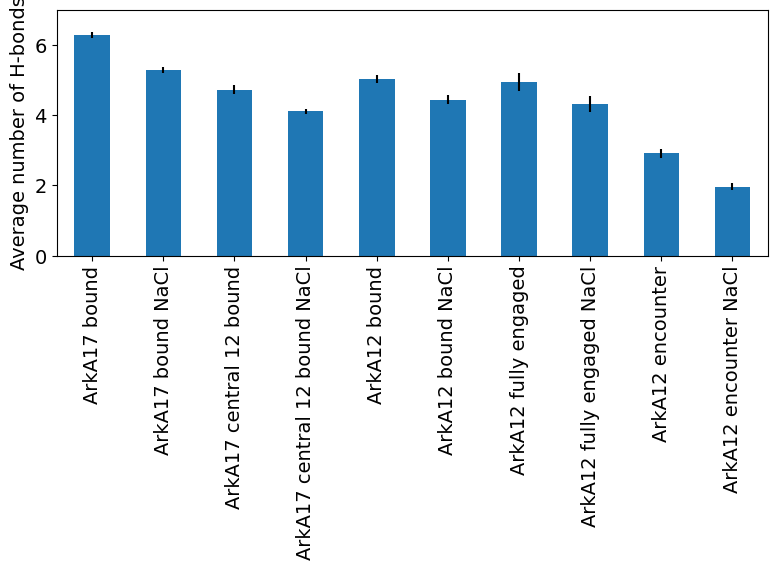

In [18]:
# plot of average number of h-bonds

plt.figure(figsize=(8,6))
plt.rcParams.update({'font.size': 14})
ax2 = avg_hb.iloc[0].plot(kind='bar', width=0.5, yerr=std_hb.iloc[0])
ax2.set_ylim(0,7)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=90)
ax2.set_ylabel("Average number of H-bonds")
#plt.title('Average number of hydrogen bonds', fontsize=16)
plt.tight_layout()
#plt.savefig('/data/kball/SH3_binding/salt_paper_analysis/figures/Avg_hbonds_ArkA_complex.pdf', dpi=1000)

Current dimensions: 9.0 x 7.0 inches
New dimensions: 2.25 x 1.75 inches


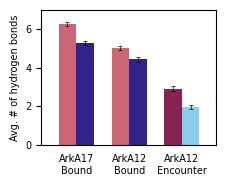

In [19]:
# plot of average number of h-bonds

#plt.figure(figsize=(8,6))
#plt.rcParams.update({'font.size': 14})
#ax2 = avg_hb.iloc[0].plot(kind='bar', width=0.5, yerr=std_hb.iloc[0])
#ax2.set_ylim(0,7)
#ax2.set_xticklabels(ax2.get_xticklabels(), rotation=90)
#ax2.set_ylabel("Average number of H-bonds")
##plt.title('Average number of hydrogen bonds', fontsize=16)
#plt.tight_layout()

x = np.arange(1)  # X coordinates for each group
#print(x)
width = 0.41
sep = 0.2

plt.figure(figsize=(9,7))
#ax = total_electrostat_frac_bound.mean().plot.bar(yerr=total_electrostat_frac_bound.sem(), width=0.5, rot=45)
#fig = plt.gcf()
#ax.set_ylabel('Avg. # Electrostatic Interactions')
#plt.bar(x - width/2, total_electrostat_frac_bound.mean(), width, 
        #yerr=total_electrostat_frac_bound.sem())
    
# Plotting the no salt bound sims ArkA17
plt.bar(x - 9*width/2 - sep, avg_hb.iloc[0,0], width, color='#CC6677',
        yerr=std_hb.iloc[0,0], error_kw={'elinewidth': 0.5, "capsize": 1.5, "capthick": 0.5})


# Plotting the salt bound sims ArkA17
plt.bar(x - 7*width/2 - sep, avg_hb.iloc[0,1], width, color='#332288',
        yerr=std_hb.iloc[0,1], error_kw={'elinewidth': 0.5, "capsize": 1.5, "capthick": 0.5})


# Plotting the no salt bound sims ArkA12
plt.bar(x - 3*width/2 - sep, avg_hb.iloc[0,4], width, color='#CC6677',
        yerr=std_hb.iloc[0,4], error_kw={'elinewidth': 0.5, "capsize": 1.5, "capthick": 0.5})


# Plotting the salt bound sims) ArkA12
plt.bar(x - width/2 - sep, avg_hb.iloc[0,5], width, color='#332288',
        yerr=std_hb.iloc[0,5], error_kw={'elinewidth': 0.5, "capsize": 1.5, "capthick": 0.5})


# Plotting the no salt encounter sims ArkA12
plt.bar(x + width/2 + sep, avg_hb.iloc[0,8], width, color='#882255',
        yerr=std_hb.iloc[0,8], error_kw={'elinewidth': 0.5, "capsize": 1.5, "capthick": 0.5})


# Plotting the salt encounter sims ArkA12
plt.bar(x + 3*width/2 + sep, avg_hb.iloc[0,9], width, color='#88CCEE',
        yerr=std_hb.iloc[0,8], error_kw={'elinewidth': 0.5, "capsize": 1.5, "capthick": 0.5})

plt.xlim(-0.05 -13*sep,1 + 2*sep)
plt.ylim(0,7)
# Set x-axis ticks as original index
plt.xticks([-3*width - 3*sep, -width - sep, width + sep], ["ArkA17\nBound", "ArkA12\nBound", "ArkA12\nEncounter"], fontsize=7)
plt.tick_params(bottom=False)
plt.yticks(np.arange(0, 7, 2), fontsize=7)
#ax.set_yticks(np.arange(0, 1.25, 0.25))

# Add legend, xlabel, ylabel, and title
plt.ylabel('Avg. # of hydrogen bonds', fontsize=7)
#plt.text(-1.00, 0.40, "no\nsalt", color='white', fontsize=7)
#plt.text(-0.97+width, 0.40, "salt", color='white', fontsize=7)
#plt.text(0.21, 0.40, "no\nsalt", color='white', fontsize=7)
#plt.text(0.24+width, 0.40, "salt", color='white', fontsize=7)
#plt.title('ArkA17 Bound', fontsize=18)

# Get the current figure
fig = plt.gcf()

# Get the current dimensions
current_width, current_height = fig.get_size_inches()
print(f"Current dimensions: {current_width} x {current_height} inches")

# Define the new width
new_width = 2.25 # inches

# Calculate the new height to maintain the aspect ratio
aspect_ratio = current_height / current_width
new_height = new_width * aspect_ratio
print(f"New dimensions: {new_width} x {new_height} inches")

# Set the new figure size
fig.set_size_inches(new_width, new_height)

# Save the figure
plt.savefig('avg_hbonds.png', dpi=1000, bbox_inches='tight')

plt.show()

In [20]:
avg_hb

,ArkA17 bound,ArkA17 bound NaCl,ArkA17 central 12 bound,ArkA17 central 12 bound NaCl,ArkA12 bound,ArkA12 bound NaCl,ArkA12 fully engaged,ArkA12 fully engaged NaCl,ArkA12 encounter,ArkA12 encounter NaCl
num h-bonds,6.267946,5.281312,4.721493,4.098519,5.025194,4.438578,4.941249,4.306689,2.907271,1.960639


In [54]:
std_hb

,ArkA17 bound,ArkA17 bound NaCl,ArkA17 central 12 bound,ArkA17 central 12 bound NaCl,ArkA12 bound,ArkA12 bound NaCl,ArkA12 fully engaged,ArkA12 fully engaged NaCl,ArkA12 encounter,ArkA12 encounter NaCl
0,0.084118,0.079016,0.119022,0.077762,0.121863,0.132514,0.24982,0.229787,0.122171,0.096734


# sigificance testing

In [21]:
# ArkA17 bound effect of NaCl
ArkA17_avg_hb_values = np.concatenate([avg_hb_by_sim["ArkA17 bound"].dropna().values,
                                           avg_hb_by_sim["ArkA17 bound NaCl"].dropna().values])
#calculate the real difference, no salt minus salt
diff_ArkA17_data = (np.mean(ArkA17_avg_hb_values[0:num_ArkA17_bound_sims]) 
             - np.mean(ArkA17_avg_hb_values[num_ArkA17_bound_sims:num_ArkA17_bound_sims 
                                                + num_ArkA17_bound_NaCl_sims]))

print("ArkA17 bound 800 mM NaCl vs no-salt difference = " , diff_ArkA17_data)

#sample 10000 times and calculate differences
numsample = 10000
diff_ArkA17_samples = [0]*numsample
diff_ArkA17_samples_larger = [0]*numsample
for sample in range(0,len(diff_ArkA17_samples)):
    random_groups = np.random.permutation(ArkA17_avg_hb_values)
    diff_ArkA17_samples[sample] = (np.mean(random_groups[0:num_ArkA17_bound_sims]) 
             - np.mean(random_groups[num_ArkA17_bound_sims:num_ArkA17_bound_sims 
                                                + num_ArkA17_bound_NaCl_sims]))
    if diff_ArkA17_samples[sample] >= diff_ArkA17_data:
        diff_ArkA17_samples_larger[sample] = 1

#calculate p-value
pval_diff_ArkA17 = (1 + np.sum(diff_ArkA17_samples_larger))/(numsample + 1)
print("p-value = " , pval_diff_ArkA17)

ArkA17 bound 800 mM NaCl vs no-salt difference =  0.9866336111111114
p-value =  9.999000099990002e-05


In [22]:
# ArkA17 central 12 bound effect of NaCl
ArkA17c_avg_hb_values = np.concatenate([avg_hb_by_sim["ArkA17 central 12 bound"].dropna().values,
                                           avg_hb_by_sim["ArkA17 central 12 bound NaCl"].dropna().values])
#calculate the real difference, no salt minus salt
diff_ArkA17c_data = (np.mean(ArkA17c_avg_hb_values[0:num_ArkA17_bound_sims]) 
             - np.mean(ArkA17c_avg_hb_values[num_ArkA17_bound_sims:num_ArkA17_bound_sims 
                                                + num_ArkA17_bound_NaCl_sims]))

print("ArkA17 central 12 bound 800 mM NaCl vs no-salt difference = " , diff_ArkA17c_data)

#sample 10000 times and calculate differences
numsample = 10000
diff_ArkA17c_samples = [0]*numsample
diff_ArkA17c_samples_larger = [0]*numsample
for sample in range(0,len(diff_ArkA17c_samples)):
    random_groups = np.random.permutation(ArkA17c_avg_hb_values)
    diff_ArkA17c_samples[sample] = (np.mean(random_groups[0:num_ArkA17_bound_sims]) 
             - np.mean(random_groups[num_ArkA17_bound_sims:num_ArkA17_bound_sims 
                                                + num_ArkA17_bound_NaCl_sims]))
    if diff_ArkA17c_samples[sample] >= diff_ArkA17c_data:
        diff_ArkA17c_samples_larger[sample] = 1

#calculate p-value
pval_diff_ArkA17c = (1 + np.sum(diff_ArkA17c_samples_larger))/(numsample + 1)
print("p-value = " , pval_diff_ArkA17c)

ArkA17 central 12 bound 800 mM NaCl vs no-salt difference =  0.6229744444444449
p-value =  0.0008999100089991


In [23]:
# ArkA12 bound effect of NaCl
ArkA12bound_avg_hb_values = np.concatenate([avg_hb_by_sim["ArkA12 bound"].dropna().values,
                                           avg_hb_by_sim["ArkA12 bound NaCl"].dropna().values])
#calculate the real difference, no salt minus salt
diff_ArkA12bound_data = (np.mean(ArkA12bound_avg_hb_values[0:num_ArkA12_bound_sims]) 
             - np.mean(ArkA12bound_avg_hb_values[num_ArkA12_bound_sims:num_ArkA12_bound_sims 
                                                + num_ArkA12_bound_NaCl_sims]))

print("ArkA12 bound 800 mM NaCl vs no-salt difference = " , diff_ArkA12bound_data)

#sample 10000 times and calculate differences
numsample = 10000
diff_ArkA12bound_samples = [0]*numsample
diff_ArkA12bound_samples_larger = [0]*numsample
for sample in range(0,len(diff_ArkA12bound_samples)):
    random_groups = np.random.permutation(ArkA12bound_avg_hb_values)
    diff_ArkA12bound_samples[sample] = (np.mean(random_groups[0:num_ArkA12_bound_sims]) 
             - np.mean(random_groups[num_ArkA12_bound_sims:num_ArkA12_bound_sims 
                                                + num_ArkA12_bound_NaCl_sims]))
    if diff_ArkA12bound_samples[sample] >= diff_ArkA12bound_data:
        diff_ArkA12bound_samples_larger[sample] = 1

#calculate p-value
pval_diff_ArkA12bound = (1 + np.sum(diff_ArkA12bound_samples_larger))/(numsample + 1)
print("p-value = " , pval_diff_ArkA12bound)

ArkA12 bound 800 mM NaCl vs no-salt difference =  0.5866158333333331
p-value =  0.0022997700229977


In [24]:
# ArkA12 fully engaged effect of NaCl
ArkA12fe_avg_hb_values = np.concatenate([avg_hb_by_sim["ArkA12 fully engaged"].dropna().values,
                                           avg_hb_by_sim["ArkA12 fully engaged NaCl"].dropna().values])
#calculate the real difference, no salt minus salt
diff_ArkA12fe_data = (np.mean(ArkA12fe_avg_hb_values[0:len(avg_hb_by_sim["ArkA12 fully engaged"].dropna())]) 
             - np.mean(ArkA12fe_avg_hb_values[len(avg_hb_by_sim["ArkA12 fully engaged"].dropna()):len(avg_hb_by_sim["ArkA12 fully engaged"].dropna()) 
                                                + len(avg_hb_by_sim["ArkA12 fully engaged NaCl"].dropna())]))

print("ArkA12 fully engaged 800 mM NaCl vs no-salt difference = " , diff_ArkA12fe_data)

#sample 10000 times and calculate differences
numsample = 10000
diff_ArkA12fe_samples = [0]*numsample
diff_ArkA12fe_samples_larger = [0]*numsample
for sample in range(0,len(diff_ArkA12fe_samples)):
    random_groups = np.random.permutation(ArkA12fe_avg_hb_values)
    diff_ArkA12fe_samples[sample] = (np.mean(random_groups[0:len(avg_hb_by_sim["ArkA12 fully engaged"].dropna())]) 
             - np.mean(random_groups[len(avg_hb_by_sim["ArkA12 fully engaged"].dropna()):len(avg_hb_by_sim["ArkA12 fully engaged"].dropna()) 
                                                + len(avg_hb_by_sim["ArkA12 fully engaged NaCl"].dropna())]))
    if diff_ArkA12fe_samples[sample] >= diff_ArkA12fe_data:
        diff_ArkA12fe_samples_larger[sample] = 1

#calculate p-value
pval_diff_ArkA12fe = (1 + np.sum(diff_ArkA12fe_samples_larger))/(numsample + 1)
print("p-value = " , pval_diff_ArkA12fe)

ArkA12 fully engaged 800 mM NaCl vs no-salt difference =  0.3907392350682777
p-value =  0.16868313168683133


In [25]:
# ArkA12 encounter effect of NaCl
ArkA12encounter_avg_hb_values = np.concatenate([avg_hb_by_sim["ArkA12 encounter"].dropna().values,
                                           avg_hb_by_sim["ArkA12 encounter NaCl"].dropna().values])
#calculate the real difference, no salt minus salt
diff_ArkA12encounter_data = (np.mean(ArkA12encounter_avg_hb_values[0:num_ArkA12_binding_sims]) 
             - np.mean(ArkA12encounter_avg_hb_values[num_ArkA12_binding_sims:num_ArkA12_binding_sims 
                                                + num_ArkA12_binding_NaCl_sims]))

print("ArkA12 encounter 800 mM NaCl vs no-salt difference = " , diff_ArkA12encounter_data)

#sample 10000 times and calculate differences
numsample = 10000
diff_ArkA12encounter_samples = [0]*numsample
diff_ArkA12encounter_samples_larger = [0]*numsample
for sample in range(0,len(diff_ArkA12encounter_samples)):
    random_groups = np.random.permutation(ArkA12encounter_avg_hb_values)
    diff_ArkA12encounter_samples[sample] = (np.mean(random_groups[0:num_ArkA12_binding_sims]) 
             - np.mean(random_groups[num_ArkA12_binding_sims:num_ArkA12_binding_sims 
                                                + num_ArkA12_binding_NaCl_sims]))
    if diff_ArkA12encounter_samples[sample] >= diff_ArkA12encounter_data:
        diff_ArkA12encounter_samples_larger[sample] = 1

#calculate p-value
pval_diff_ArkA12encounter = (1 + np.sum(diff_ArkA12encounter_samples_larger))/(numsample + 1)
print("p-value = " , pval_diff_ArkA12encounter)

ArkA12 encounter 800 mM NaCl vs no-salt difference =  0.8587417251404641
p-value =  9.999000099990002e-05


## Look at the P(2) to Y54 hbond

In [26]:
# read in data on the P(2)-Y54 h-bond

ArkA17_bound_P2_Y54 = pd.read_table(
    '/data/kball/SH3_binding/salt_paper_analysis/AbpSH3_ArkA17/P2_Y54.dat', sep = '\s+')
ArkA17_bound_NaCl_P2_Y54 = pd.read_table(
    '/data/kball/SH3_binding/salt_paper_analysis/AbpSH3_ArkA17_NaCl/P2_Y54.dat', sep = '\s+')

# switch to Ally's data
ArkA12_bound_P2_Y54 = pd.read_table(
    '/data/kball/SH3_binding/binding_paper_analysis/hydrophobics/bound/P2_Y54.dat', sep = '\s+')
#
ArkA12_bound_NaCl_P2_Y54 = pd.read_table(
    '/data/kball/SH3_binding/salt_paper_analysis/AbpSH3_ArkA12_NaCl/P2_Y54.dat', sep = '\s+')

ArkA12_binding_P2_Y54 = pd.read_table(
    '/data/kball/SH3_binding/binding_paper_analysis/hydrophobics/ArkA12_binding/P2_Y54.dat', sep = '\s+')
ArkA12_binding_NaCl_P2_Y54 = pd.read_table(
    '/data/mcohen3/SH3/analysis/hbonds/P2_Y54.dat', sep = '\s+')


In [27]:
# determine fraction of simulation where it is present for bound simulations

P2_Y54_hb = pd.DataFrame(columns=['ArkA17 bound'])

ArkA17_bound_P2_Y54 = ArkA17_bound_P2_Y54.drop(['#Frame'], axis=1)
ArkA17_bound_P2_Y54.columns = ['fraction']
P2_Y54_hb.loc['fraction','ArkA17 bound'] = np.mean(ArkA17_bound_P2_Y54['fraction'] > 0)

ArkA17_bound_NaCl_P2_Y54 = ArkA17_bound_NaCl_P2_Y54.drop(['#Frame'], axis=1)
ArkA17_bound_NaCl_P2_Y54.columns = ['fraction']
P2_Y54_hb.loc['fraction','ArkA17 bound NaCl'] = np.mean(ArkA17_bound_NaCl_P2_Y54['fraction'] > 0)

ArkA12_bound_P2_Y54 = ArkA12_bound_P2_Y54.drop(['#Frame'], axis=1)
ArkA12_bound_P2_Y54.columns = ['fraction']
P2_Y54_hb.loc['fraction','ArkA12 bound'] = np.mean(ArkA12_bound_P2_Y54['fraction'] > 0)

ArkA12_bound_NaCl_P2_Y54 = ArkA12_bound_NaCl_P2_Y54.drop(['#Frame'], axis=1)
ArkA12_bound_NaCl_P2_Y54.columns = ['fraction']
P2_Y54_hb.loc['fraction','ArkA12 bound NaCl'] = np.mean(ArkA12_bound_NaCl_P2_Y54['fraction'] > 0)

P2_Y54_hb

,ArkA17 bound,ArkA17 bound NaCl,ArkA12 bound,ArkA12 bound NaCl
fraction,0.87343,0.884431,0.878736,0.883924


In [28]:
# determine standard error for bound simulations

# P2_Y54_hb_std = pd.DataFrame(columns=['ArkA17 bound'])
# frac_by_sim = pd.DataFrame(columns=['ArkA17 bound'])

# for sim in range(0,num_ArkA17_bound_sims):
#     frac_by_sim = frac_by_sim.append({'ArkA17 bound': 
#                                           np.mean(ArkA17_bound_P2_Y54[sim*num_ArkA17_bound_snapshots:(sim+1)*num_ArkA17_bound_snapshots]['fraction'] > 0)}, 
#                                          ignore_index=True)
# P2_Y54_hb_std.loc['fraction','ArkA17 bound'] = frac_by_sim.sem()['ArkA17 bound']    

# for sim in range(0,num_ArkA17_bound_NaCl_sims):
#     frac_by_sim = frac_by_sim.append({'ArkA17 bound NaCl': 
#                                           np.mean(ArkA17_bound_NaCl_P2_Y54[sim*num_ArkA17_bound_NaCl_snapshots:(sim+1)*num_ArkA17_bound_NaCl_snapshots]['fraction'] > 0)}, 
#                                          ignore_index=True)
# P2_Y54_hb_std.loc['fraction','ArkA17 bound NaCl'] = frac_by_sim.sem()['ArkA17 bound NaCl']    

# for sim in range(0,num_ArkA12_bound_sims):
#     frac_by_sim = frac_by_sim.append({'ArkA12 bound': 
#                                           np.mean(ArkA12_bound_P2_Y54[sim*num_ArkA12_bound_snapshots:(sim+1)*num_ArkA12_bound_snapshots]['fraction'] > 0)}, 
#                                          ignore_index=True)
# P2_Y54_hb_std.loc['fraction','ArkA12 bound'] = frac_by_sim.sem()['ArkA12 bound']    

# for sim in range(0,num_ArkA12_bound_NaCl_sims):
#     frac_by_sim = frac_by_sim.append({'ArkA12 bound NaCl': 
#                                           np.mean(ArkA12_bound_NaCl_P2_Y54[sim*num_ArkA12_bound_NaCl_snapshots:(sim+1)*num_ArkA12_bound_NaCl_snapshots]['fraction'] > 0)}, 
#                                          ignore_index=True)
# P2_Y54_hb_std.loc['fraction','ArkA12 bound NaCl'] = frac_by_sim.sem()['ArkA12 bound NaCl']  

# P2_Y54_hb_std

In [29]:
P2_Y54_hb_std = pd.DataFrame(columns=['ArkA17 bound', 'ArkA17 bound NaCl', 'ArkA17 central 12 bound', 'ArkA17 central 12 bound NaCl', 'ArkA12 bound', 'ArkA12 bound NaCl', 'ArkA12 fully engaged'])

# Create separate DataFrames for each condition
P2_Y54_hb_data = {}

P2_Y54_hb_data['ArkA17 bound'] = [ArkA17_bound_P2_Y54[sim * num_ArkA17_bound_snapshots : (sim + 1) * num_ArkA17_bound_snapshots].mean()[0] for sim in range(num_ArkA17_bound_sims)]
P2_Y54_hb_data['ArkA17 bound NaCl'] = [ArkA17_bound_NaCl_P2_Y54[sim * num_ArkA17_bound_NaCl_snapshots : (sim + 1) * num_ArkA17_bound_NaCl_snapshots].mean()[0] for sim in range(num_ArkA17_bound_NaCl_sims)]
P2_Y54_hb_data['ArkA12 bound'] = [ArkA12_bound_P2_Y54[sim * num_ArkA12_bound_snapshots : (sim + 1) * num_ArkA12_bound_snapshots].mean()[0] for sim in range(num_ArkA12_bound_sims)]
P2_Y54_hb_data['ArkA12 bound NaCl'] = [ArkA12_bound_NaCl_P2_Y54[sim * num_ArkA12_bound_NaCl_snapshots : (sim + 1) * num_ArkA12_bound_NaCl_snapshots].mean()[0] for sim in range(num_ArkA12_bound_NaCl_sims)]

# Convert dictionaries to DataFrames
P2_Y54_hb_dfs = {key: pd.DataFrame({key: value}) for key, value in P2_Y54_hb_data.items()}

# Join all DataFrames on their index
P2_Y54_avg_hb_by_sim = P2_Y54_hb_dfs.pop('ArkA17 bound')
for df in P2_Y54_hb_dfs.values():
    P2_Y54_avg_hb_by_sim = P2_Y54_avg_hb_by_sim.join(df, how='outer')

# Compute standard error for each condition
P2_Y54_hb_std.loc['fraction'] = P2_Y54_avg_hb_by_sim.sem()

/tmp/ipykernel_2766302/2750007188.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  P2_Y54_hb_data['ArkA17 bound'] = [ArkA17_bound_P2_Y54[sim * num_ArkA17_bound_snapshots : (sim + 1) * num_ArkA17_bound_snapshots].mean()[0] for sim in range(num_ArkA17_bound_sims)]
/tmp/ipykernel_2766302/2750007188.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  P2_Y54_hb_data['ArkA17 bound NaCl'] = [ArkA17_bound_NaCl_P2_Y54[sim * num_ArkA17_bound_NaCl_snapshots : (sim + 1) * num_ArkA17_bound_NaCl_snapshots].mean()[0] for sim in range(num_ArkA17_bound_NaCl_sims)]
/tmp/ipykernel_2766302/2750007188.py:8: FutureWarning: Series.__get

In [30]:
ArkA12_binding_NaCl_P2_Y54

,#Frame,HB_00016[UU]
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0
...,...,...
4999995,4999996,0
4999996,4999997,0
4999997,4999998,0
4999998,4999999,0


In [31]:
# determine fraction of simulation where it is present for binding simulations

ArkA12_binding_P2_Y54 = ArkA12_binding_P2_Y54.drop(['#Frame'], axis=1)
ArkA12_binding_P2_Y54.columns = ['fraction']
ArkA12_binding_P2_Y54['status'] = arka12_stat['status']

ArkA12_binding_NaCl_P2_Y54 = ArkA12_binding_NaCl_P2_Y54.drop(['#Frame'], axis=1)
ArkA12_binding_NaCl_P2_Y54.columns = ['fraction']
ArkA12_binding_NaCl_P2_Y54['status'] = arka12_NaCl_stat['status']


P2_Y54_bound_hb = ArkA12_binding_P2_Y54[(ArkA12_binding_P2_Y54['status'] == 'Bound')]
P2_Y54_bound_hb = P2_Y54_bound_hb.drop(['status'], axis=1)
P2_Y54_hb.loc['fraction','ArkA12 fully engaged'] = np.mean(P2_Y54_bound_hb['fraction'] > 0)

P2_Y54_bound_NaCl_hb = ArkA12_binding_NaCl_P2_Y54[(ArkA12_binding_NaCl_P2_Y54['status'] == 'Bound')]
P2_Y54_bound_NaCl_hb = P2_Y54_bound_NaCl_hb.drop(['status'], axis=1)
P2_Y54_hb.loc['fraction','ArkA12 fully engaged NaCl'] = np.mean(P2_Y54_bound_NaCl_hb['fraction'] > 0)


P2_Y54_encounter_hb = ArkA12_binding_P2_Y54[(ArkA12_binding_P2_Y54['status'] != 'unbound') & 
                                            (ArkA12_binding_P2_Y54['status'] != 'Bound')]
P2_Y54_encounter_hb = P2_Y54_encounter_hb.drop(['status'], axis=1)
P2_Y54_hb.loc['fraction','ArkA12 encounter'] = np.mean(P2_Y54_encounter_hb['fraction'] > 0)

P2_Y54_encounter_NaCl_hb = ArkA12_binding_NaCl_P2_Y54[(ArkA12_binding_NaCl_P2_Y54['status'] != 'unbound') & 
                                            (ArkA12_binding_NaCl_P2_Y54['status'] != 'Bound')]
P2_Y54_encounter_NaCl_hb = P2_Y54_encounter_NaCl_hb.drop(['status'], axis=1)
P2_Y54_hb.loc['fraction','ArkA12 encounter NaCl'] = np.mean(P2_Y54_encounter_NaCl_hb['fraction'] > 0)

P2_Y54_hb

,ArkA17 bound,ArkA17 bound NaCl,ArkA12 bound,ArkA12 bound NaCl,ArkA12 fully engaged,ArkA12 fully engaged NaCl,ArkA12 encounter,ArkA12 encounter NaCl
fraction,0.87343,0.884431,0.878736,0.883924,0.678986,0.783734,0.032433,0.020911


In [32]:
# determine standard error for binding simulations fully-engaged state

#for sim in range(0,num_ArkA12_binding_sims):
#    by_sim = ArkA12_binding_P2_Y54[sim*num_ArkA12_binding_snapshots:(sim+1)*num_ArkA12_binding_snapshots]
#    status_sim = by_sim[(by_sim['status'] == 'Bound')]
#    frac_by_sim = frac_by_sim.append({'ArkA12 fully engaged': np.mean(status_sim['fraction'] > 0)}, ignore_index=True)
#P2_Y54_hb_std.loc['fraction','ArkA12 fully engaged'] = frac_by_sim.sem()['ArkA12 fully engaged']
#print(frac_by_sim)

#P2_Y54_hb_std

In [33]:
# Determine standard error for binding simulations fully-engaged state
frac_by_sim = pd.DataFrame(columns=['ArkA12 fully engaged'])
frac_list = []
for sim in range(num_ArkA12_binding_sims):
    by_sim = ArkA12_binding_P2_Y54[sim*num_ArkA12_binding_snapshots:(sim+1)*num_ArkA12_binding_snapshots]
    status_sim = by_sim[by_sim['status'] == 'Bound']
    frac_list.append(np.mean(status_sim['fraction'] > 0))

frac_by_sim['ArkA12 fully engaged'] = frac_list

# Directly assign the standard error to avoid column conflicts
P2_Y54_hb_std.loc['fraction', 'ArkA12 fully engaged'] = frac_by_sim.sem()['ArkA12 fully engaged']

P2_Y54_hb_std

,ArkA17 bound,ArkA17 bound NaCl,ArkA17 central 12 bound,ArkA17 central 12 bound NaCl,ArkA12 bound,ArkA12 bound NaCl,ArkA12 fully engaged
fraction,0.006772,0.004557,NaN,NaN,0.009357,0.011431,0.074162


In [34]:
frac_by_sim

,ArkA12 fully engaged
0,0.000000
1,0.118477
2,NaN
3,NaN
4,0.000000
5,0.285714
6,NaN
7,0.910808
8,0.838490
9,0.000000


In [35]:
# determine standard error for binding simulations fully-engaged state in NaCl

#for sim in range(0,num_ArkA12_binding_NaCl_sims):
#    by_sim = ArkA12_binding_NaCl_P2_Y54[sim*num_ArkA12_binding_NaCl_snapshots:(sim+1)*num_ArkA12_binding_NaCl_snapshots]
#    status_sim = by_sim[(by_sim['status'] == 'Bound')]
#    frac_by_sim = frac_by_sim.append({'ArkA12 fully engaged NaCl': np.mean(status_sim['fraction'] > 0)}, ignore_index=True)
#P2_Y54_hb_std.loc['fraction','ArkA12 fully engaged NaCl'] = frac_by_sim.sem()['ArkA12 fully engaged NaCl']

#P2_Y54_hb_std

# Determine standard error for binding simulations fully-engaged state
frac_list = []
for sim in range(num_ArkA12_binding_NaCl_sims):
    by_sim = ArkA12_binding_NaCl_P2_Y54[sim*num_ArkA12_binding_NaCl_snapshots:(sim+1)*num_ArkA12_binding_NaCl_snapshots]
    status_sim = by_sim[by_sim['status'] == 'Bound']
    frac_list.append(np.mean(status_sim['fraction'] > 0))

frac_by_sim['ArkA12 fully engaged NaCl'] = frac_list

# Directly assign the standard error to avoid column conflicts
P2_Y54_hb_std.loc['fraction', 'ArkA12 fully engaged NaCl'] = frac_by_sim.sem()['ArkA12 fully engaged NaCl']

P2_Y54_hb_std

,ArkA17 bound,ArkA17 bound NaCl,ArkA17 central 12 bound,ArkA17 central 12 bound NaCl,ArkA12 bound,ArkA12 bound NaCl,ArkA12 fully engaged,ArkA12 fully engaged NaCl
fraction,0.006772,0.004557,NaN,NaN,0.009357,0.011431,0.074162,0.11123


In [36]:
# determine standard error for binding simulations encounter state

#for sim in range(0,num_ArkA12_binding_sims):
#    by_sim = ArkA12_binding_P2_Y54[sim*num_ArkA12_binding_snapshots:(sim+1)*num_ArkA12_binding_snapshots]
#    status_sim = by_sim[(by_sim['status'] != 'unbound') & (by_sim['status'] != 'Bound')]
#    frac_by_sim = frac_by_sim.append({'ArkA12 encounter': np.mean(status_sim['fraction'] > 0)}, ignore_index=True)
#P2_Y54_hb_std.loc['fraction','ArkA12 encounter'] = frac_by_sim.sem()['ArkA12 encounter']

#P2_Y54_hb_std

# Determine standard error for binding simulations fully-engaged state
frac_list = []
for sim in range(num_ArkA12_binding_sims):
    by_sim = ArkA12_binding_P2_Y54[sim*num_ArkA12_binding_snapshots:(sim+1)*num_ArkA12_binding_snapshots]
    status_sim = by_sim[(by_sim['status'] != 'unbound') & (by_sim['status'] != 'Bound')]
    frac_list.append(np.mean(status_sim['fraction'] > 0))

frac_by_sim['ArkA12 encounter'] = frac_list

# Directly assign the standard error to avoid column conflicts
P2_Y54_hb_std.loc['fraction', 'ArkA12 encounter'] = frac_by_sim.sem()['ArkA12 encounter']

P2_Y54_hb_std

,ArkA17 bound,ArkA17 bound NaCl,ArkA17 central 12 bound,ArkA17 central 12 bound NaCl,ArkA12 bound,ArkA12 bound NaCl,ArkA12 fully engaged,ArkA12 fully engaged NaCl,ArkA12 encounter
fraction,0.006772,0.004557,NaN,NaN,0.009357,0.011431,0.074162,0.11123,0.014294


In [52]:
frac_by_sim

,ArkA12 fully engaged,ArkA12 fully engaged NaCl,ArkA12 encounter,ArkA12 encounter NaCl
0,0.000000,0.902827,0.000000,0.073018
1,0.118477,NaN,0.007289,0.000000
2,NaN,NaN,0.087369,0.000060
3,NaN,NaN,0.000000,0.000000
4,0.000000,NaN,0.000000,0.000000
5,0.285714,NaN,0.000495,0.000000
6,NaN,0.000000,0.000000,0.044686
7,0.910808,0.000000,0.150985,0.000000
8,0.838490,NaN,0.002592,0.008297
9,0.000000,NaN,0.000000,0.000000


In [37]:
# determine standard error for binding simulations encounter state in NaCl

#for sim in range(0,num_ArkA12_binding_NaCl_sims):
#    by_sim = ArkA12_binding_NaCl_P2_Y54[sim*num_ArkA12_binding_NaCl_snapshots:(sim+1)*num_ArkA12_binding_NaCl_snapshots]
#    status_sim = by_sim[(by_sim['status'] != 'unbound') & (by_sim['status'] != 'Bound')]
#    frac_by_sim = frac_by_sim.append({'ArkA12 encounter NaCl': np.mean(status_sim['fraction'] > 0)}, ignore_index=True)
#P2_Y54_hb_std.loc['fraction','ArkA12 encounter NaCl'] = frac_by_sim.sem()['ArkA12 encounter NaCl']

#P2_Y54_hb_std

# Determine standard error for binding simulations fully-engaged state
frac_list = []
for sim in range(num_ArkA12_binding_NaCl_sims):
    by_sim = ArkA12_binding_NaCl_P2_Y54[sim*num_ArkA12_binding_NaCl_snapshots:(sim+1)*num_ArkA12_binding_NaCl_snapshots]
    status_sim = by_sim[(by_sim['status'] != 'unbound') & (by_sim['status'] != 'Bound')]
    frac_list.append(np.mean(status_sim['fraction'] > 0))

frac_by_sim['ArkA12 encounter NaCl'] = frac_list

# Directly assign the standard error to avoid column conflicts
P2_Y54_hb_std.loc['fraction', 'ArkA12 encounter NaCl'] = frac_by_sim.sem()['ArkA12 encounter NaCl']

P2_Y54_hb_std

,ArkA17 bound,ArkA17 bound NaCl,ArkA17 central 12 bound,ArkA17 central 12 bound NaCl,ArkA12 bound,ArkA12 bound NaCl,ArkA12 fully engaged,ArkA12 fully engaged NaCl,ArkA12 encounter,ArkA12 encounter NaCl
fraction,0.006772,0.004557,NaN,NaN,0.009357,0.011431,0.074162,0.11123,0.014294,0.020423


In [38]:
# Not dividing up by states within encounter for now

# P2_Y54_fwd_hb = ArkA12_binding_P2_Y54[(ArkA12_binding_P2_Y54['status'] == 'Fwd')]
# P2_Y54_fwd_hb = P2_Y54_fwd_hb.drop(['status'], axis=1)
# P2_Y54_hb.loc['fraction','ArkA fwd'] = np.mean(P2_Y54_fwd_hb['fraction'] > 0)

# P2_Y54_rev_hb = ArkA12_binding_P2_Y54[(ArkA12_binding_P2_Y54['status'] == 'Rev')]
# P2_Y54_rev_hb = P2_Y54_rev_hb.drop(['status'], axis=1)
# P2_Y54_hb.loc['fraction','ArkA rev'] = np.mean(P2_Y54_rev_hb['fraction'] > 0)

# P2_Y54_seg2_hb = ArkA12_binding_P2_Y54[(ArkA12_binding_P2_Y54['status'] == 'seg2 only')]
# P2_Y54_seg2_hb = P2_Y54_seg2_hb.drop(['status'], axis=1)
# P2_Y54_hb.loc['fraction','ArkA seg2'] = np.mean(P2_Y54_seg2_hb['fraction'] > 0)

# P2_Y54_partial_hb = ArkA12_binding_P2_Y54[(ArkA12_binding_P2_Y54['status'] == 'partial')]
# P2_Y54_partial_hb = P2_Y54_partial_hb.drop(['status'], axis=1)
# P2_Y54_hb.loc['fraction','ArkA other'] = np.mean(P2_Y54_partial_hb['fraction'] > 0)

# P2_Y54_unbound_hb = ArkA12_binding_P2_Y54[ArkA12_binding_P2_Y54['status'] == 'unbound']
# P2_Y54_unbound_hb = P2_Y54_unbound_hb.drop(['status'], axis=1)
# P2_Y54_hb.loc['fraction','ArkA unbound'] = np.mean(P2_Y54_unbound_hb['fraction'] > 0)

# P2_Y54_hb

In [39]:
# Not dividing up by states within encounter for now

# for sim in range(0,num_binding_sims):
#     by_sim = ArkA12_binding_P2_Y54[sim*num_binding_snapshots:(sim+1)*num_binding_snapshots]
#     status_sim = by_sim[(by_sim['status'] == 'Fwd')]
#     frac_by_sim = frac_by_sim.append({'ArkA fwd': np.mean(status_sim['fraction'] > 0)}, ignore_index=True)
# P2_Y54_hb_std.loc['fraction','ArkA fwd'] = frac_by_sim.std()['ArkA fwd']

# for sim in range(0,num_binding_sims):
#     by_sim = ArkA12_binding_P2_Y54[sim*num_binding_snapshots:(sim+1)*num_binding_snapshots]
#     status_sim = by_sim[(by_sim['status'] == 'Rev')]
#     frac_by_sim = frac_by_sim.append({'ArkA rev': np.mean(status_sim['fraction'] > 0)}, ignore_index=True)
# P2_Y54_hb_std.loc['fraction','ArkA rev'] = frac_by_sim.std()['ArkA rev']

# for sim in range(0,num_binding_sims):
#     by_sim = ArkA12_binding_P2_Y54[sim*num_binding_snapshots:(sim+1)*num_binding_snapshots]
#     status_sim = by_sim[(by_sim['status'] == 'seg2 only')]
#     frac_by_sim = frac_by_sim.append({'ArkA seg2': np.mean(status_sim['fraction'] > 0)}, ignore_index=True)
# P2_Y54_hb_std.loc['fraction','ArkA seg2'] = frac_by_sim.std()['ArkA seg2']

# for sim in range(0,num_binding_sims):
#     by_sim = ArkA12_binding_P2_Y54[sim*num_binding_snapshots:(sim+1)*num_binding_snapshots]
#     status_sim = by_sim[(by_sim['status'] == 'partial')]
#     frac_by_sim = frac_by_sim.append({'ArkA other': np.mean(status_sim['fraction'] > 0)}, ignore_index=True)
# P2_Y54_hb_std.loc['fraction','ArkA other'] = frac_by_sim.std()['ArkA other']

# for sim in range(0,num_binding_sims):
#     by_sim = ArkA12_binding_P2_Y54[sim*num_binding_snapshots:(sim+1)*num_binding_snapshots]
#     status_sim = by_sim[(by_sim['status'] == 'unbound')]
#     frac_by_sim = frac_by_sim.append({'ArkA unbound': np.mean(status_sim['fraction'] > 0)}, ignore_index=True)
# P2_Y54_hb_std.loc['fraction','ArkA unbound'] = frac_by_sim.std()['ArkA unbound']

# P2_Y54_hb_std

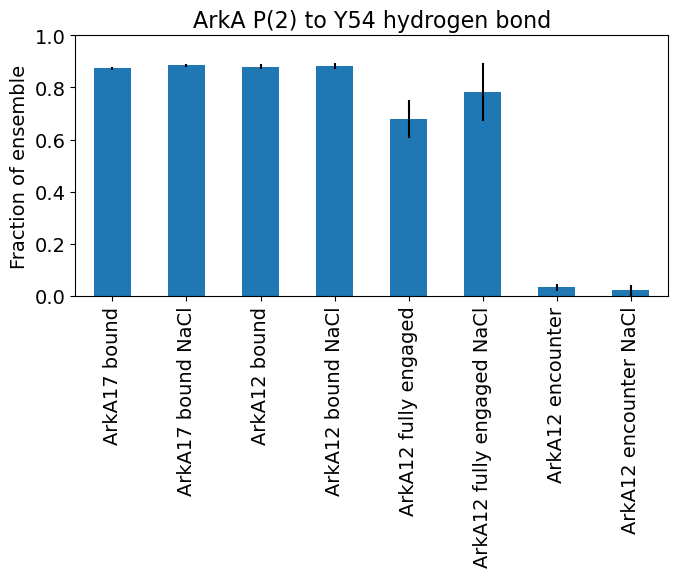

In [40]:
# Make figure for P(2) to Y54 h-bond

plt.figure(figsize=(7,6))
plt.rcParams.update({'font.size': 14})
ax2 = P2_Y54_hb.iloc[0].plot(kind='bar', width=0.5, yerr=P2_Y54_hb_std.iloc[0])
ax2.set_ylim(0,1)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=90)
ax2.set_ylabel("Fraction of ensemble")
plt.title('ArkA P(2) to Y54 hydrogen bond', fontsize=16)
plt.tight_layout()
#plt.savefig('/data/kball/SH3_binding/salt_paper_analysis/figures/P2_Y54_hbond_ArkA_complex.pdf', dpi=1000)

Current dimensions: 9.0 x 7.0 inches
New dimensions: 2.25 x 1.75 inches


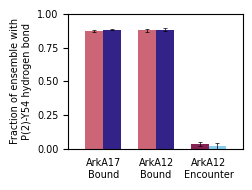

In [41]:
x = np.arange(1)  # X coordinates for each group
#print(x)
width = 0.41
sep = 0.2

plt.figure(figsize=(9,7))
#ax = total_electrostat_frac_bound.mean().plot.bar(yerr=total_electrostat_frac_bound.sem(), width=0.5, rot=45)
#fig = plt.gcf()
#ax.set_ylabel('Avg. # Electrostatic Interactions')
#plt.bar(x - width/2, total_electrostat_frac_bound.mean(), width, 
        #yerr=total_electrostat_frac_bound.sem())
    

# Plotting the no salt bound sims ArkA17
plt.bar(x - 9*width/2 - sep, P2_Y54_hb.iloc[0,0], width, color='#CC6677',
        yerr=P2_Y54_hb_std.iloc[0,0], error_kw={'elinewidth': 0.5, "capsize": 1.5, "capthick": 0.5})


# Plotting the salt bound sims) ArkA17
plt.bar(x - 7*width/2 - sep, P2_Y54_hb.iloc[0,1], width, color='#332288',
        yerr=P2_Y54_hb_std.iloc[0,1], error_kw={'elinewidth': 0.5, "capsize": 1.5, "capthick": 0.5})

# Plotting the no salt bound sims ArkA12
plt.bar(x - 3*width/2 - sep, P2_Y54_hb.iloc[0,2], width, color='#CC6677',
        yerr=P2_Y54_hb_std.iloc[0,4], error_kw={'elinewidth': 0.5, "capsize": 1.5, "capthick": 0.5})


# Plotting the salt bound sims) ArkA12
plt.bar(x - width/2 - sep, P2_Y54_hb.iloc[0,3], width, color='#332288',
        yerr=P2_Y54_hb_std.iloc[0,5], error_kw={'elinewidth': 0.5, "capsize": 1.5, "capthick": 0.5})


# Plotting the no salt encounter sims ArkA12
plt.bar(x + width/2 + sep, P2_Y54_hb.iloc[0,6], width, color='#882255',
        yerr=P2_Y54_hb_std.iloc[0,8], error_kw={'elinewidth': 0.5, "capsize": 1.5, "capthick": 0.5})


# Plotting the salt encounter sims ArkA12
plt.bar(x + 3*width/2 + sep, P2_Y54_hb.iloc[0,7], width, color='#88CCEE',
        yerr=P2_Y54_hb_std.iloc[0,9], error_kw={'elinewidth': 0.5, "capsize": 1.5, "capthick": 0.5})

plt.xlim(-0.05 - 13*sep,1 + 2*sep)
plt.ylim(0,1)
# Set x-axis ticks as original index
plt.xticks([-3*width - 3*sep, -width - sep, width + sep], ["ArkA17\nBound", "ArkA12\nBound", "ArkA12\nEncounter"], fontsize=7)
plt.yticks(np.arange(0, 1.25, 0.25), fontsize=7)
plt.tick_params(bottom=False)

# Add legend, xlabel, ylabel, and title
plt.ylabel('Fraction of ensemble with\nP(2)-Y54 hydrogen bond', fontsize=7)
#plt.text(-1.00, 0.10, "no\nsalt", color='white', fontsize=7)
#plt.text(-0.97+width, 0.10, "salt", color='white', fontsize=7)
#plt.text(0.21, 0.10, "no\nsalt", color='black', fontsize=7)
#plt.text(0.24+width, 0.10, "salt", color='black', fontsize=7)
#plt.title('ArkA17 Bound', fontsize=18)

# Get the current figure
fig = plt.gcf()

# Get the current dimensions
current_width, current_height = fig.get_size_inches()
print(f"Current dimensions: {current_width} x {current_height} inches")

# Define the new width
new_width = 2.25 # inches

# Calculate the new height to maintain the aspect ratio
aspect_ratio = current_height / current_width
new_height = new_width * aspect_ratio
print(f"New dimensions: {new_width} x {new_height} inches")

# Set the new figure size
fig.set_size_inches(new_width, new_height)

# Save the figure
plt.savefig('p2-y54_hbond.png', dpi=1000, bbox_inches='tight')

plt.show()

In [42]:
P2_Y54_hb

,ArkA17 bound,ArkA17 bound NaCl,ArkA12 bound,ArkA12 bound NaCl,ArkA12 fully engaged,ArkA12 fully engaged NaCl,ArkA12 encounter,ArkA12 encounter NaCl
fraction,0.87343,0.884431,0.878736,0.883924,0.678986,0.783734,0.032433,0.020911


In [43]:
P2_Y54_hb_std

,ArkA17 bound,ArkA17 bound NaCl,ArkA17 central 12 bound,ArkA17 central 12 bound NaCl,ArkA12 bound,ArkA12 bound NaCl,ArkA12 fully engaged,ArkA12 fully engaged NaCl,ArkA12 encounter,ArkA12 encounter NaCl
fraction,0.006772,0.004557,NaN,NaN,0.009357,0.011431,0.074162,0.11123,0.014294,0.020423


# sigificance testing

In [47]:
P2_Y54_avg_hb_by_sim

,ArkA17 bound,ArkA17 bound NaCl,ArkA12 bound,ArkA12 bound NaCl
0,0.873537,0.884889,0.893371,0.888096
1,0.880533,0.902944,0.870075,0.789987
2,0.889242,0.909856,0.900092,0.869296
3,0.883008,0.892433,0.860659,0.906571
4,0.892663,0.883444,NaN,0.901979
5,0.889892,0.882111,NaN,0.892067
6,0.819100,0.898589,NaN,0.902563
7,0.878142,0.894156,NaN,0.886725
8,0.879067,0.858700,NaN,0.909713
9,0.889204,0.879122,NaN,0.912571


In [48]:
# ArkA17 bound effect of NaCl
ArkA17_P2_Y54_hb_values = np.concatenate([P2_Y54_avg_hb_by_sim["ArkA17 bound"].dropna().values,
                                           P2_Y54_avg_hb_by_sim["ArkA17 bound NaCl"].dropna().values])
#calculate the real difference, no salt minus salt
diff_ArkA17_data = (np.mean(ArkA17_P2_Y54_hb_values[0:num_ArkA17_bound_sims]) 
             - np.mean(ArkA17_P2_Y54_hb_values[num_ArkA17_bound_sims:num_ArkA17_bound_sims 
                                                + num_ArkA17_bound_NaCl_sims]))

print("ArkA17 bound 800 mM NaCl vs no-salt difference = " , diff_ArkA17_data)

#sample 10000 times and calculate differences
numsample = 10000
diff_ArkA17_samples = [0]*numsample
diff_ArkA17_samples_larger = [0]*numsample
for sample in range(0,len(diff_ArkA17_samples)):
    random_groups = np.random.permutation(ArkA17_P2_Y54_hb_values)
    diff_ArkA17_samples[sample] = (np.mean(random_groups[0:num_ArkA17_bound_sims]) 
             - np.mean(random_groups[num_ArkA17_bound_sims:num_ArkA17_bound_sims 
                                                + num_ArkA17_bound_NaCl_sims]))
    if diff_ArkA17_samples[sample] >= diff_ArkA17_data:
        diff_ArkA17_samples_larger[sample] = 1

#calculate p-value
pval_diff_ArkA17 = (1 + np.sum(diff_ArkA17_samples_larger))/(numsample + 1)
print("p-value = " , pval_diff_ArkA17)

ArkA17 bound 800 mM NaCl vs no-salt difference =  -0.011185694444444394
p-value =  0.9006099390060994


In [49]:
# ArkA12 bound effect of NaCl
ArkA12bound_P2_Y54_hb_values = np.concatenate([P2_Y54_avg_hb_by_sim["ArkA12 bound"].dropna().values,
                                           P2_Y54_avg_hb_by_sim["ArkA12 bound NaCl"].dropna().values])
#calculate the real difference, no salt minus salt
diff_ArkA12bound_data = (np.mean(ArkA12bound_P2_Y54_hb_values[0:num_ArkA12_bound_sims]) 
             - np.mean(ArkA12bound_P2_Y54_hb_values[num_ArkA12_bound_sims:num_ArkA12_bound_sims 
                                                + num_ArkA12_bound_NaCl_sims]))

print("ArkA12 bound 800 mM NaCl vs no-salt difference = " , diff_ArkA12bound_data)

#sample 10000 times and calculate differences
numsample = 10000
diff_ArkA12bound_samples = [0]*numsample
diff_ArkA12bound_samples_larger = [0]*numsample
for sample in range(0,len(diff_ArkA12bound_samples)):
    random_groups = np.random.permutation(ArkA12bound_P2_Y54_hb_values)
    diff_ArkA12bound_samples[sample] = (np.mean(random_groups[0:num_ArkA12_bound_sims]) 
             - np.mean(random_groups[num_ArkA12_bound_sims:num_ArkA12_bound_sims 
                                                + num_ArkA12_bound_NaCl_sims]))
    if diff_ArkA12bound_samples[sample] >= diff_ArkA12bound_data:
        diff_ArkA12bound_samples_larger[sample] = 1

#calculate p-value
pval_diff_ArkA12bound = (1 + np.sum(diff_ArkA12bound_samples_larger))/(numsample + 1)
print("p-value = " , pval_diff_ArkA12bound)

ArkA12 bound 800 mM NaCl vs no-salt difference =  -0.02567349144535236
p-value =  0.9671032896710329


In [ ]:
# ArkA12 fully engaged effect of NaCl
ArkA12fe_P2_Y54_hb_values = np.concatenate([frac_by_sim["ArkA12 fully engaged"].dropna().values,
                                           frac_by_sim["ArkA12 fully engaged NaCl"].dropna().values])
#calculate the real difference, no salt minus salt
diff_ArkA12fe_data = (np.mean(ArkA12fe_P2_Y54_hb_values[0:len(frac_by_sim["ArkA12 fully engaged"].dropna())]) 
             - np.mean(ArkA12fe_P2_Y54_hb_values[len(frac_by_sim["ArkA12 fully engaged"].dropna()):len(frac_by_sim["ArkA12 fully engaged"].dropna()) 
                                                + len(frac_by_sim["ArkA12 fully engaged NaCl"].dropna())]))

print("ArkA12 fully engaged 800 mM NaCl vs no-salt difference = " , diff_ArkA12fe_data)

#sample 10000 times and calculate differences
numsample = 10000
diff_ArkA12fe_samples = [0]*numsample
diff_ArkA12fe_samples_larger = [0]*numsample
for sample in range(0,len(diff_ArkA12fe_samples)):
    random_groups = np.random.permutation(ArkA12fe_P2_Y54_hb_values)
    diff_ArkA12fe_samples[sample] = (np.mean(random_groups[0:len(frac_by_sim["ArkA12 fully engaged"].dropna())]) 
             - np.mean(random_groups[len(frac_by_sim["ArkA12 fully engaged"].dropna()):len(frac_by_sim["ArkA12 fully engaged"].dropna()) 
                                                + len(frac_by_sim["ArkA12 fully engaged NaCl"].dropna())]))
    if diff_ArkA12fe_samples[sample] >= diff_ArkA12fe_data:
        diff_ArkA12fe_samples_larger[sample] = 1

#calculate p-value
pval_diff_ArkA12fe = (1 + np.sum(diff_ArkA12fe_samples_larger))/(numsample + 1)
print("p-value = " , pval_diff_ArkA12fe)

In [51]:
P2_Y54_encounter_hb['fraction'] > 0

634        False
635        False
636        False
641        False
642        False
           ...  
4999995    False
4999996    False
4999997    False
4999998    False
4999999    False
Name: fraction, Length: 3810801, dtype: bool

In [53]:
# ArkA12 encounter effect of NaCl
ArkA12encounter_P2_Y54_hb_values = np.concatenate([frac_by_sim["ArkA12 encounter"].dropna().values,
                                           frac_by_sim["ArkA12 encounter NaCl"].dropna().values])
#calculate the real difference, no salt minus salt
diff_ArkA12encounter_data = (np.mean(ArkA12encounter_P2_Y54_hb_values[0:num_ArkA12_binding_sims]) 
             - np.mean(ArkA12encounter_P2_Y54_hb_values[num_ArkA12_binding_sims:num_ArkA12_binding_sims 
                                                + num_ArkA12_binding_NaCl_sims]))

print("ArkA12 encounter 800 mM NaCl vs no-salt difference = " , diff_ArkA12encounter_data)

#sample 10000 times and calculate differences
numsample = 10000
diff_ArkA12encounter_samples = [0]*numsample
diff_ArkA12encounter_samples_larger = [0]*numsample
for sample in range(0,len(diff_ArkA12encounter_samples)):
    random_groups = np.random.permutation(ArkA12encounter_P2_Y54_hb_values)
    diff_ArkA12encounter_samples[sample] = (np.mean(random_groups[0:num_ArkA12_binding_sims]) 
             - np.mean(random_groups[num_ArkA12_binding_sims:num_ArkA12_binding_sims 
                                                + num_ArkA12_binding_NaCl_sims]))
    if diff_ArkA12encounter_samples[sample] >= diff_ArkA12encounter_data:
        diff_ArkA12encounter_samples_larger[sample] = 1

#calculate p-value
pval_diff_ArkA12encounter = (1 + np.sum(diff_ArkA12encounter_samples_larger))/(numsample + 1)
print("p-value = " , pval_diff_ArkA12encounter)

ArkA12 encounter 800 mM NaCl vs no-salt difference =  -0.009311419475354965
p-value =  0.6386361363863614
